# VAE condicional

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import tqdm
from matplotlib import pyplot as plt
from torch import optim

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = 'mps'

## Datos de entrenamiento

In [2]:
transf = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])
dataset = datasets.FashionMNIST('data', train=True, transform=transf, download=True)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=True)

def show_batch(images):
    grid_tensor = utils.make_grid(images, nrow=10)
    plt.axis('off')
    plt.imshow(1-grid_tensor.permute(1, 2, 0))
    plt.tight_layout()
    plt.show()

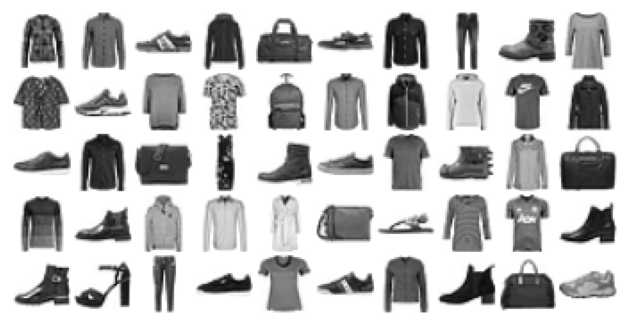

In [3]:
batch_x, batch_y = next(iter(dataloader))
show_batch(batch_x[:50])

## Redes neuronales

### Encoder

In [4]:
class ImageEncoder(nn.Module):

    def __init__(self, image_size, latent_dim, n_classes):
        super().__init__()

        self.n_classes = n_classes

        conv = lambda in_ch, out_ch: nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1)
        c, h, w = image_size
        flatten_dim = 64 * (h // 8) * (w // 8)

        self.encoder = nn.Sequential(
            conv(c + n_classes, 16), nn.ReLU(),
            conv(16, 32), nn.ReLU(),
            conv(32, 64), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(flatten_dim, 2 * latent_dim)
        )

    def forward(self, x, y):

        batch_size, c, h, w = x.shape
        y_emb = F.one_hot(y, self.n_classes)  # [batch_size, n_classes].
        y_emb = y_emb[:, :, None, None].expand(batch_size, self.n_classes, h, w)  # [batch_size, n_classes, h, w].

        x_cond = torch.cat([x, y_emb], dim=1)  # [batch_size, c + n_classes, h, w].

        mean, logstd = self.encoder(x_cond).chunk(2, dim=-1)
        std = logstd.exp()
        return mean, std

In [5]:
# Ejemplo de uso:

batch_size, image_size, latent_dim, n_classes = 100, (1, 32, 32), 16, 10

image_encoder = ImageEncoder(image_size, latent_dim, n_classes)
x = torch.randn(batch_size, *image_size)
y = torch.randint(0, n_classes, (batch_size,))
mean, std = image_encoder(x, y)

assert mean.shape == (batch_size, latent_dim)
assert std.shape == (batch_size, latent_dim)

### Decoder

In [ ]:
class ImageDecoder(nn.Module):

    def __init__(self, image_size, latent_dim, n_classes):
        super().__init__()

        c, h, w = image_size
        flatten_dim = 64 * (h // 8) * (w // 8)
        self.n_classes = n_classes

        deconv = lambda in_ch, out_ch: nn.ConvTranspose2d(in_ch, out_ch, 3, 2, 1, 1)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + n_classes, flatten_dim),
            nn.ReLU(),
            nn.Unflatten(1, (64, h // 8, w // 8)),
            deconv(64, 32), nn.ReLU(),
            deconv(32, 16), nn.ReLU(),
            deconv(16, c), nn.Sigmoid()
        )

    def forward(self, z, y):
        y_onehot = F.one_hot(y, self.n_classes)  # [batch_size, n_classes].
        z_cond = torch.cat([z, y_onehot], dim=-1)  # [batch_size, latent_dim + n_classes].
        x_hat = self.decoder(z_cond)
        return x_hat

In [7]:
# Ejemplo de uso:

batch_size, image_size, latent_dim, n_classes = 100, (1, 32, 32), 16, 10

image_decoder = ImageDecoder(image_size, latent_dim, n_classes)
x = torch.randn(batch_size, latent_dim)
y = torch.randint(0, n_classes, (batch_size,))
x_hat = image_decoder(x, y)

assert x_hat.shape == (batch_size, *image_size)

## Clase `ImageVAE`

In [ ]:
class ImageVAE:

    def __init__(self, image_size=(1, 32, 32), latent_dim=128, n_classes=10):

        self.image_size = image_size
        self.latent_dim = latent_dim

        self.encoder = ImageEncoder(image_size, latent_dim, n_classes)
        self.decoder = ImageDecoder(image_size, latent_dim, n_classes)
        
        self.encoder_optimizer = optim.AdamW(self.encoder.parameters())
        self.decoder_optimizer = optim.AdamW(self.decoder.parameters())

        self.encoder.to(DEVICE)
        self.decoder.to(DEVICE)

    def train(self, dataloader, epochs):

        self.encoder.train()
        self.decoder.train()

        try:
            for epoch in tqdm.trange(epochs):

                for x, y in dataloader:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    loss = self._calc_loss(x, y)

                    # Optimización:
                    self.encoder_optimizer.zero_grad()
                    self.decoder_optimizer.zero_grad()
                    loss.backward()
                    self.encoder_optimizer.step()
                    self.decoder_optimizer.step()

        except KeyboardInterrupt:
            print('Entrenamiento interrumpido.')

    def _calc_loss(self, x, y):

        # Prior matching:
        encoder_mean, encoder_std = self.encoder(x, y)
        prior_matching = 1/2 * (encoder_mean.norm(dim=-1) ** 2 + encoder_std.norm(dim=-1) ** 2) - encoder_std.log().sum(dim=-1)

        # Término de reconstrucción:
        z = encoder_mean + encoder_std * torch.randn_like(encoder_mean)
        x_hat = self.decoder(z, y)
        x = x.flatten(start_dim=1)  # [batch_size, c * h * w]
        x_hat = x_hat.flatten(start_dim=1)  # [batch_size, c * h * w]
        reconstruction_term = (x * x_hat.log() + (1 - x) * (1 - x_hat).log()).sum(dim=-1)

        elbo = reconstruction_term - prior_matching
        return - elbo.mean()

    def generate_samples(self, y, n_samples):

        self.decoder.eval()

        with torch.no_grad():
            y = torch.tensor(y, device=DEVICE).expand(n_samples)
            z = torch.randn(n_samples, self.latent_dim, device=DEVICE)
            x_hat = self.decoder(z, y)

        return x_hat

In [9]:
vae = ImageVAE()
vae.train(dataloader, epochs=50)

100%|██████████| 50/50 [04:05<00:00,  4.91s/it]


## Generación

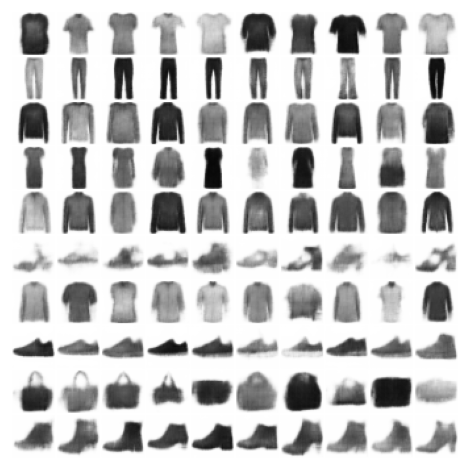

In [14]:
samples = [vae.generate_samples(y, n_samples=10) for y in range(10)]
samples = torch.cat(samples, dim=0)
show_batch(samples.cpu())

## Reconstrucción

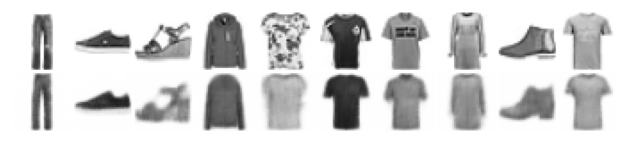

In [12]:
vae.encoder.eval()

batch_x, batch_y = next(iter(dataloader))
x = batch_x[:10].to(DEVICE)
y = batch_y[:10].to(DEVICE)

encoder_mean, encoder_std = vae.encoder(x, y)
z = encoder_mean + encoder_std * torch.randn_like(encoder_mean)
x_hat = vae.decoder(z, y)

imgs = torch.cat([x, x_hat], dim=0)
show_batch(imgs.cpu())